In [1]:
import pandas as pd
# Load dataset
df=pd.read_csv("netflix_titles.csv")

# Fill missing values in important columns
df["director"]=df["director"].fillna("Unknown")
df["cast"]=df["cast"].fillna("Unknown")
df["country"]=df["country"].fillna("Other")

# Fill missing duration based on type (Movie / TV Show)
df.loc[df['type'] == 'Movie', 'duration'] = df.loc[df['type'] == 'Movie', 'duration'].fillna('90 min')
df.loc[df['type'] == 'TV Show', 'duration'] = df.loc[df['type'] == 'TV Show', 'duration'].fillna('1 Season')

# Fill missing ratings
df['rating'] = df['rating'].fillna('Not Rated')

# Remove rows where 'date_added' is missing
df=df.dropna(subset=["date_added"])

# Remove extra spaces and convert to datetime format
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

# Remove leading and trailing spaces from all text columns
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

# Remove duplicate records
df = df.drop_duplicates()

# Standardize column names (lowercase + replace spaces with underscore)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

C:\Users\SHRAVYA HEGDE\AppData\Local\Temp\ipykernel_11604\575228288.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


In [2]:
df['listed_in'].str.split(',').explode().str.strip().value_counts()

listed_in
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1350
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
Thrillers                        577
TV Comedies                      574
Crime TV Shows                   469
Kids' TV                         449
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 252
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     175
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows             

In [3]:
df['year_added'] = df['date_added'].dt.year

In [4]:
wrong_ratings = ['74 min', '84 min', '66 min']
df.loc[df['rating'].isin(wrong_ratings), 'rating'] = 'NR'

In [5]:

df['rating'] = df['rating'].replace({'Not Rated': 'NR', 'UR': 'NR'})
print(df['rating'].value_counts())

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            89
G             41
TV-Y7-FV       6
NC-17          3
Name: count, dtype: int64


In [6]:
# Fix title column - movie/show titles may have newlines
df['title'] = df['title'].str.replace('\n', ' ', regex=False)

# Fix description column - long descriptions often have newlines
df['description'] = df['description'].str.replace('\n', ' ', regex=False)

# Fix cast column - multiple cast members may have newlines
df['cast'] = df['cast'].str.replace('\n', ' ', regex=False)

# Fix director column - may have newlines in rare cases
df['director'] = df['director'].str.replace('\n', ' ', regex=False)

# Fix country column - multiple countries may have newlines
df['country'] = df['country'].str.replace('\n', ' ', regex=False)

# Fix listed_in column - multiple genres may have newlines
df['listed_in'] = df['listed_in'].str.replace('\n', ' ', regex=False)

# Fix duration column - just in case
df['duration'] = df['duration'].str.replace('\n', ' ', regex=False)

# Fix rating column - just in case
df['rating'] = df['rating'].str.replace('\n', ' ', regex=False)


In [7]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Netflix theme colors
BG    = '#141414'
RED1  = '#E50914'
RED2  = '#B20710'
RED3  = '#831010'
RED4  = '#5C0C0C'
WHITE = '#FFFFFF'
GRAY  = '#AAAAAA'

def style_ax(ax, fig):
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=WHITE, labelsize=11)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.title.set_color(WHITE)

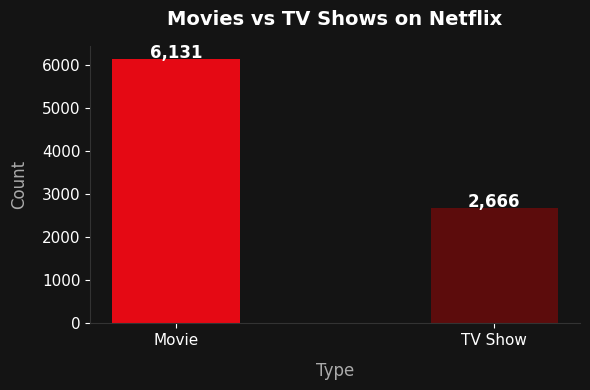

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
style_ax(ax, fig)

counts = df['type'].value_counts()
bars = ax.bar(counts.index, counts.values, color=[RED1, RED4], width=0.4, edgecolor='none')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', color=WHITE, fontsize=12, fontweight='bold')

ax.set_title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Type', fontsize=12, labelpad=10)
ax.set_ylabel('Count', fontsize=12, labelpad=10)
ax.yaxis.set_visible(True)
ax.set_axisbelow(True)
ax.grid(False)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#333333')
plt.tight_layout()
plt.show()

## Insight

Most content on Netflix consists of Movies compared to TV Shows.

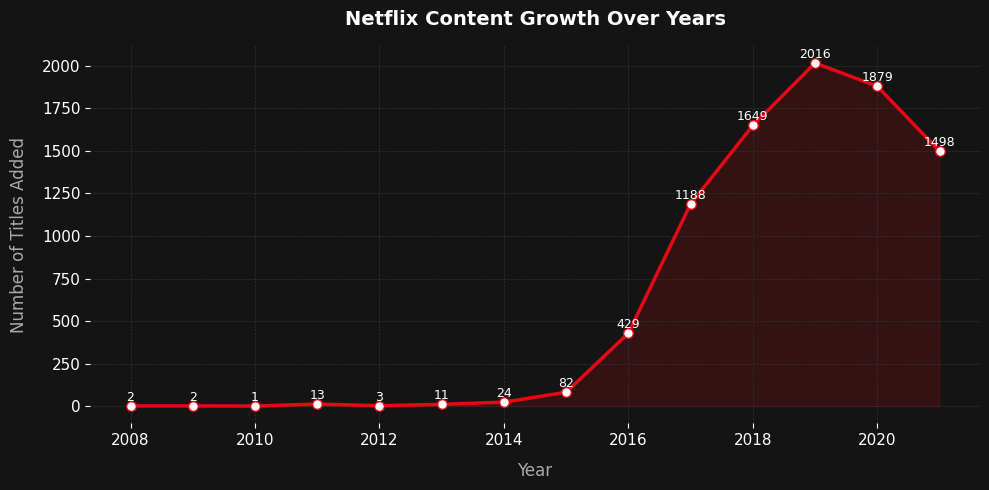

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
style_ax(ax, fig)

yearly = df['year_added'].value_counts().sort_index()
ax.plot(yearly.index, yearly.values, color=RED1, marker='o',
        markersize=7, linewidth=2.5, markerfacecolor=WHITE)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color=RED1)

for x, y in zip(yearly.index, yearly.values):
    ax.text(x, y + 30, str(y), ha='center', color=WHITE, fontsize=9)

ax.set_title('Netflix Content Growth Over Years', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Titles Added', fontsize=12, labelpad=10)
ax.tick_params(colors=WHITE)
ax.grid( color='#333333', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Insight

Netflix content has grown significantly over the years, especially after 2015, showing rapid expansion of the platform.

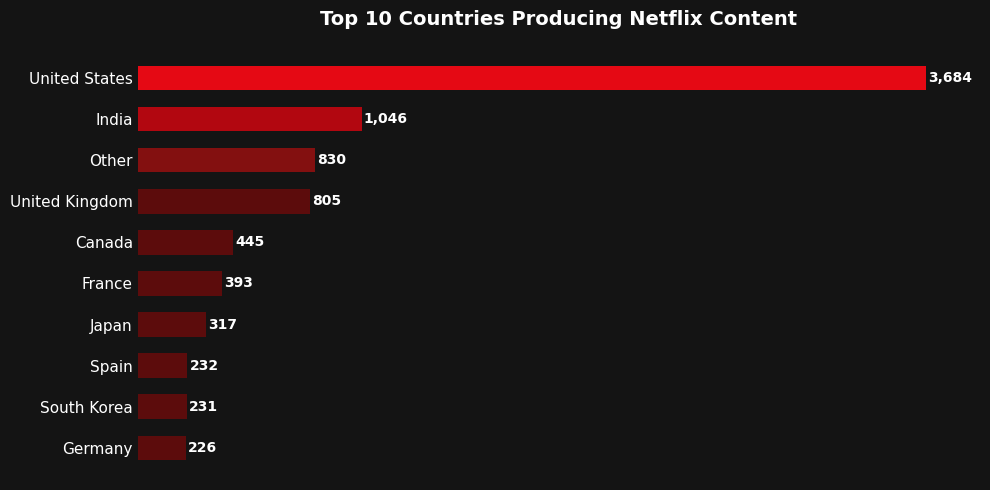

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
style_ax(ax, fig)

top_countries = df['country'].str.split(',').explode().str.strip().value_counts().head(10)
colors = [RED1, RED2, RED3] + [RED4] * 7

bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=colors[::-1], edgecolor='none', height=0.6)

for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color=WHITE, fontsize=10, fontweight='bold')

ax.set_xlim(0, top_countries.values.max() + 250)
ax.set_title('Top 10 Countries Producing Netflix Content', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', fontsize=12, labelpad=10)
ax.xaxis.set_visible(False)
ax.grid(False)
ax.yaxis.set_tick_params(length=0)

plt.tight_layout()
plt.show()

## Insight

The United States produces the highest amount of content on Netflix, followed by countries like India and the United Kingdom. Splitting multiple country entries provides a more accurate distribution.

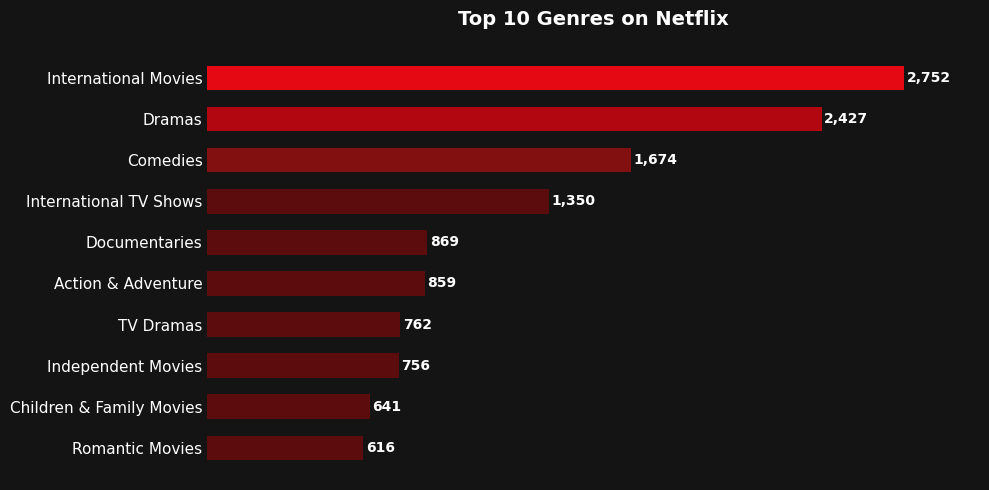

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
style_ax(ax, fig)

top_genres = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)
colors = [RED1, RED2, RED3] + [RED4] * 7

bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=colors[::-1], edgecolor='none', height=0.6)

for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color=WHITE, fontsize=10, fontweight='bold')

ax.set_xlim(0, top_genres.values.max() + 300)
ax.set_title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Titles', fontsize=12, labelpad=10)
ax.xaxis.set_visible(False)
ax.yaxis.set_tick_params(length=0)
ax.grid(False)
plt.tight_layout()
plt.show()

## Insight

Drama and International genres are the most popular on Netflix. This indicates that viewers prefer diverse and story-driven content.

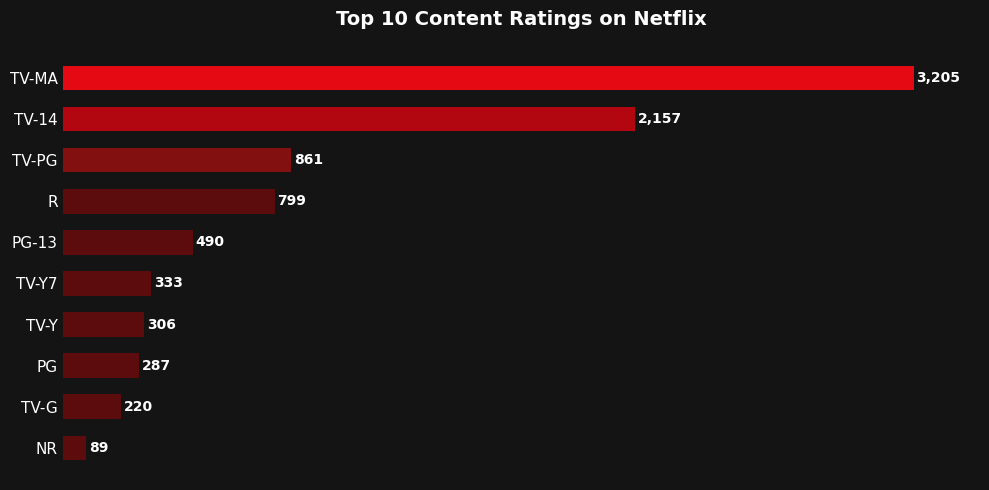

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
style_ax(ax, fig)

top_ratings = df['rating'].value_counts().head(10)
colors = [RED1, RED2, RED3] + [RED4] * 7

bars = ax.barh(top_ratings.index[::-1], top_ratings.values[::-1],
               color=colors[::-1], edgecolor='none', height=0.6)

for bar, val in zip(bars, top_ratings.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color=WHITE, fontsize=10, fontweight='bold')

ax.set_xlim(0, top_ratings.values.max() + 250)
ax.set_title('Top 10 Content Ratings on Netflix', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_visible(False)
ax.yaxis.set_tick_params(length=0)
ax.grid(False)
plt.tight_layout()
plt.show()

## Insight

The majority of Netflix content falls under the top ratings such as TV-MA and TV-14, indicating a strong focus on mature and teen audiences.

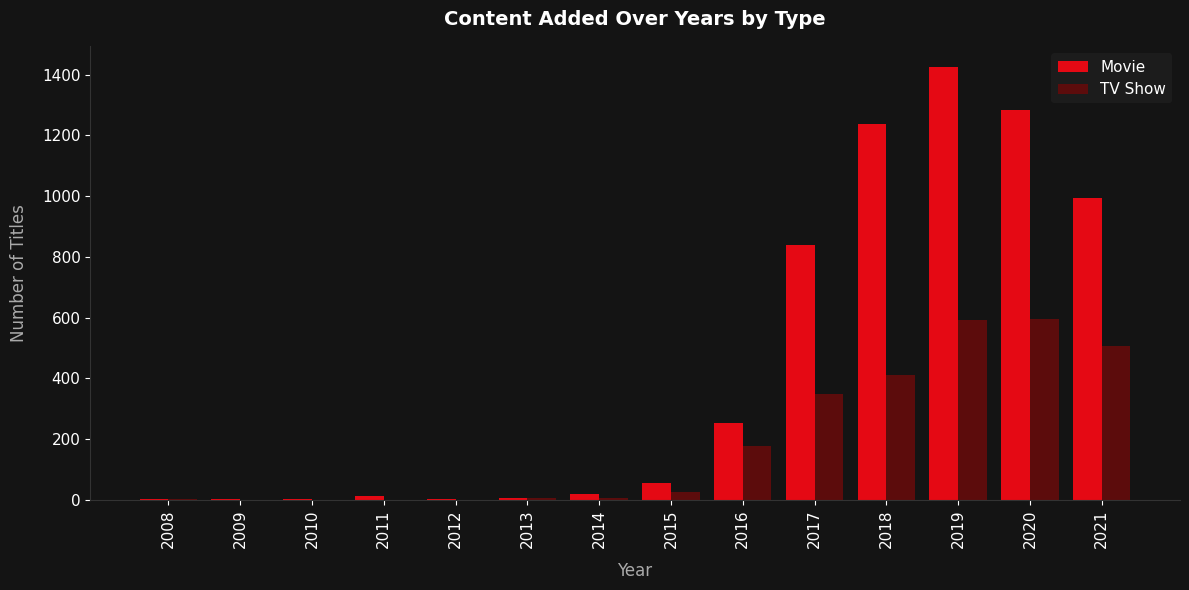

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
style_ax(ax, fig)

movies  = df[df['type'] == 'Movie']['year_added'].value_counts().sort_index()
tvshows = df[df['type'] == 'TV Show']['year_added'].value_counts().sort_index()
years   = sorted(df['year_added'].dropna().unique())
x = range(len(years))
w = 0.4

ax.bar([i - w/2 for i in x], [movies.get(y, 0) for y in years],
       width=w, color=RED1, label='Movie', edgecolor='none')
ax.bar([i + w/2 for i in x], [tvshows.get(y, 0) for y in years],
       width=w, color=RED4, label='TV Show', edgecolor='none')

ax.set_xticks(list(x))
ax.set_xticklabels([str(int(y)) for y in years], rotation=90, color=WHITE)
ax.set_title('Content Added Over Years by Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Titles', fontsize=12, labelpad=10)
ax.grid(axis='y', color='#333333', linestyle='--', linewidth=0.5)
ax.legend(facecolor='#1f1f1f', edgecolor='none', labelcolor=WHITE, fontsize=11)
ax.grid(False)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()


## Insight

Both Movies and TV Shows have increased over the years, especially after 2015. However, Movies consistently dominate the platform, although TV Shows have shown steady growth in recent years.

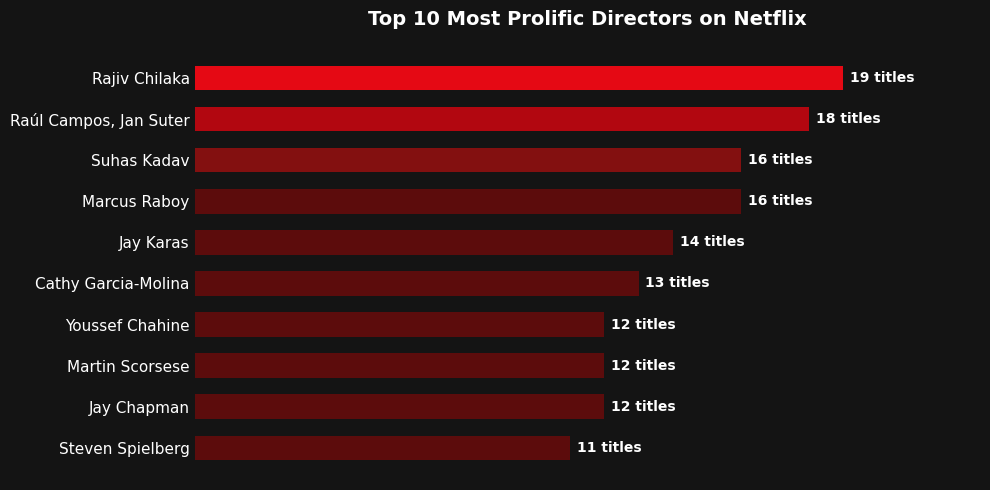

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
style_ax(ax, fig)

top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
colors = [RED1, RED2, RED3] + [RED4] * 7

bars = ax.barh(top_directors.index[::-1], top_directors.values[::-1],
               color=colors[::-1], edgecolor='none', height=0.6)

for bar, val in zip(bars, top_directors.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val} titles', va='center', color=WHITE, fontsize=10, fontweight='bold')

ax.set_xlim(0, top_directors.values.max() + 4)
ax.set_title('Top 10 Most Prolific Directors on Netflix', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_visible(False)
ax.yaxis.set_tick_params(length=0)
ax.grid(False)
plt.tight_layout()
plt.show()

## Insight

Rajiv Chilaka dominates with 19 titles through Indian kids content. International and Spanish-language documentary directors fill the top 10, reflecting Netflix's strong push into global content.

In [15]:
df.to_csv("cleaned_netflix.csv", index=False)

In [16]:
# Load your clean file
df = pd.read_csv('cleaned_netflix.csv')

# Create country dimension table
df_country = df[['show_id', 'country']].copy()

# Split multiple countries into separate rows
df_country['country'] = df_country['country'].str.split(',')
df_country = df_country.explode('country')

# Clean extra spaces
df_country['country'] = df_country['country'].str.strip()

# Remove Other rows
df_country = df_country[df_country['country'] != 'Other']

# Reset index
df_country = df_country.reset_index(drop=True)

# Save
df_country.to_csv('netflix_country.csv', index=False)

print('Main table shape:', df.shape)
print('Country table shape:', df_country.shape)
print('Sample:')
print(df_country.head(10))

Main table shape: (8797, 13)
Country table shape: (10010, 2)
Sample:
  show_id         country
0      s1   United States
1      s2    South Africa
2      s5           India
3      s8   United States
4      s8           Ghana
5      s8    Burkina Faso
6      s8  United Kingdom
7      s8         Germany
8      s8        Ethiopia
9      s9  United Kingdom


In [17]:
import pandas as pd

# Load the clean file
df = pd.read_csv('cleaned_netflix.csv')

# Create genres dimension table
df_genres = df[['show_id', 'listed_in']].copy()

# Split multiple genres into separate rows
df_genres['listed_in'] = df_genres['listed_in'].str.split(',')
df_genres = df_genres.explode('listed_in')

# Clean extra spaces
df_genres['listed_in'] = df_genres['listed_in'].str.strip()

# Rename column to genre
df_genres = df_genres.rename(columns={'listed_in': 'genre'})

# Remove empty values
df_genres = df_genres.dropna()
df_genres = df_genres[df_genres['genre'] != '']

# Reset index
df_genres = df_genres.reset_index(drop=True)

# Save
df_genres.to_csv('netflix_genres.csv', index=False)

print('Genres table shape:', df_genres.shape)
print()
print('Top 10 Genres:')
print(df_genres['genre'].value_counts().head(10))

Genres table shape: (19303, 2)

Top 10 Genres:
genre
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64
